# ReLU experiment

### Generate N * d data manifold X, with tail exponent alpha_X

### Calculate PP(X), actual alpha_X

### Apply ReLU

### Calculate PP(ReLU(X)), actual alpha_ReLUX

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [10]:
this_N = 1000
this_d = 1000

min_alpha = 0.1
max_alpha = 10.0
scale_factor = max_alpha - min_alpha
num_iterations = 100

alpha_X_vals = np.zeros(num_iterations)
actual_alpha_X_vals = np.zeros(num_iterations)
actual_alpha_reluX_vals = np.zeros(num_iterations)
pp_dim_X_vals = np.zeros(num_iterations)
pp_dim_reluX_vals = np.zeros(num_iterations)
nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_reluX_vals = np.zeros(num_iterations)

for i in range(0, num_iterations):
  this_alpha_X = min_alpha + scale_factor * (i / (num_iterations - 1))**1.5
  results_dict = pp.relu_experiment(this_N, this_d, this_alpha_X, verbose=False)
  alpha_X_vals[i] = this_alpha_X
  actual_alpha_X_vals[i] = results_dict["actual_alpha_X"]
  actual_alpha_reluX_vals[i] = results_dict["actual_alpha_reluX"]
  pp_dim_X_vals[i] = results_dict["pp_dim_X"]
  pp_dim_reluX_vals[i] = results_dict["pp_dim_reluX"]
  nu_over_d_X_vals[i] = results_dict["nu_over_d_X"]
  nu_over_d_reluX_vals[i] = results_dict["nu_over_d_reluX"]
  print(i, this_alpha_X, results_dict["actual_alpha_X"], results_dict["actual_alpha_reluX"])

0 0.1 0.2928973997630858 0.29289731755205706
1 0.11005037815259212 0.29550231545395633 0.2954909719652259
2 0.12842676218074806 0.29289331044942596 0.29289331050116496
3 0.15222329678670937 0.293192338982264 0.2931956546408389
4 0.18040302522073698 0.29289408565582525 0.29289406452956934
5 0.2123666437438737 0.29290045081032173 0.2929005261121029
6 0.2477097891751993 0.3566868288318284 0.35391710649735364
7 0.2861356082174087 0.54568360300604 0.5455896450790286
8 0.3274140974459845 0.2929342969305655 0.2929339623883928
9 0.3713602101199873 0.29530340671360883 0.2953320929989537
10 0.41782086308186417 0.2945246018710783 0.2945553166627295
11 0.4666666666666667 0.2982102975565441 0.29831842665406894
12 0.5177863742936748 0.3807491861771209 0.3783307291565472
13 0.5710829989706612 0.34359050939563796 0.34295829129375255
14 0.6264710031632484 0.49999590253471 0.4971662438969162
15 0.6838742081211423 0.6040900254599325 0.603694118522424
16 0.7432242017658958 0.5939881899244978 0.59359400240

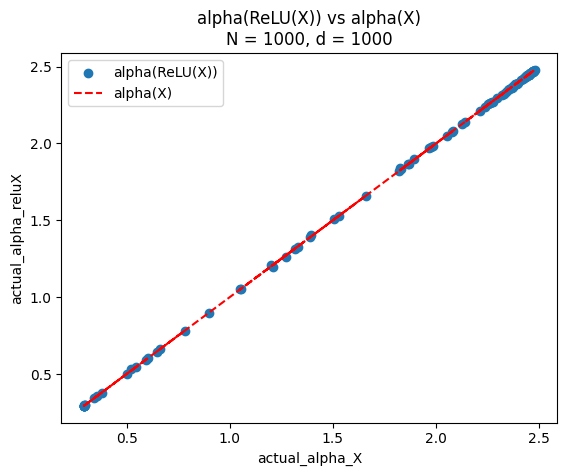

In [14]:
this_title = "alpha(ReLU(X)) vs alpha(X)\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.scatter(actual_alpha_X_vals, actual_alpha_reluX_vals, label="alpha(ReLU(X))")
plt.plot(actual_alpha_X_vals, actual_alpha_X_vals, linestyle = "--", label="alpha(X)", color = "red")
plt.xlabel("actual_alpha_X")
plt.ylabel("actual_alpha_reluX")
plt.legend()
plt.title(this_title)
plt.savefig('alpha_ReLU_X_vs_alpha_X.pdf', dpi=300, bbox_inches='tight')
plt.show()

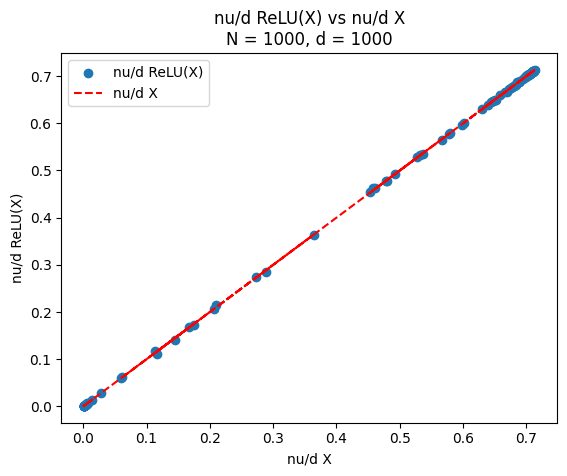

In [15]:
this_title = "nu/d ReLU(X) vs nu/d X\n"
this_title += "N = " + str(this_N) + ", d = " + str(this_d)
plt.scatter(nu_over_d_X_vals, nu_over_d_reluX_vals, label = "nu/d ReLU(X)")
plt.plot(nu_over_d_X_vals, nu_over_d_X_vals, linestyle = "--", label = "nu/d X", color = "red")
plt.xlabel("nu/d X")
plt.ylabel("nu/d ReLU(X)")
plt.legend()
plt.title(this_title)
plt.savefig('nu_over_d_ReLU_X_vs_nu_over_d_X.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Experiment n+1 : Fix N and alpha_X, let d increase from 1 to N

In [14]:
this_N = 1000
step_size = 50
these_iteration_vals = range(1, int(this_N/step_size))
num_iterations = len(these_iteration_vals)

this_alpha_X = 2.0

d_vals = np.zeros(num_iterations)
alpha_X_vals = np.zeros(num_iterations)
actual_alpha_X_vals = np.zeros(num_iterations)
actual_alpha_reluX_vals = np.zeros(num_iterations)
pp_dim_X_vals = np.zeros(num_iterations)
pp_dim_reluX_vals = np.zeros(num_iterations)
nu_over_d_X_vals = np.zeros(num_iterations)
nu_over_d_reluX_vals = np.zeros(num_iterations)

i=0
for xx in these_iteration_vals:
  this_d = xx * step_size
  this_alpha_X = 2.0
  results_dict = pp.relu_experiment(this_N, this_d, this_alpha_X, verbose=False)
  d_vals[i] = this_d
  alpha_X_vals[i] = this_alpha_X
  actual_alpha_X_vals[i] = results_dict["actual_alpha_X"]
  actual_alpha_reluX_vals[i] = results_dict["actual_alpha_reluX"]
  pp_dim_X_vals[i] = results_dict["pp_dim_X"]
  pp_dim_reluX_vals[i] = results_dict["pp_dim_reluX"]
  nu_over_d_X_vals[i] = results_dict["nu_over_d_X"]
  nu_over_d_reluX_vals[i] = results_dict["nu_over_d_reluX"]
  print(i, this_alpha_X, results_dict["actual_alpha_X"], results_dict["actual_alpha_reluX"])
  i += 1

0 2.0 1.8118359518755678 1.8037001773464725
1 2.0 2.0170566943601154 2.0257879379951804
2 2.0 1.698277471752176 1.692369048039175
3 2.0 2.1585305638839345 2.1534101435243307
4 2.0 1.838233563934644 1.8485581706000869
5 2.0 1.7692471802703573 1.7581660689827983
6 2.0 1.7116517568157756 1.7379936051727776
7 2.0 1.0100000000000002 1.0100000000000002
8 2.0 1.8451845027240805 1.8446233878145906
9 2.0 1.3144091337858614 1.3085307777101787
10 2.0 1.362052151605304 1.3567169069519613
11 2.0 1.4304799970076227 1.4278081723479157
12 2.0 1.968221005322249 1.9682047761874628
13 2.0 1.78133168771852 1.7784291787763349
14 2.0 1.6863345635947866 1.6739608327626785
15 2.0 1.2471996991889045 1.2519611944891722
16 2.0 1.3757861772901587 1.3834474697914048
17 2.0 1.7104395695362251 1.7105964755768759
18 2.0 1.7578165026984691 1.7515480946929232


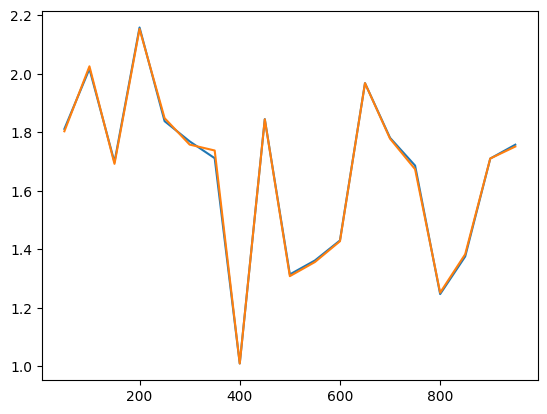

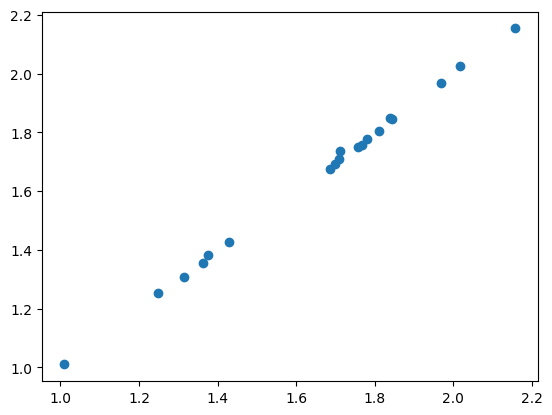

In [17]:
plt.plot(d_vals, actual_alpha_X_vals)
plt.plot(d_vals, actual_alpha_reluX_vals)
plt.show()

plt.scatter(actual_alpha_X_vals, actual_alpha_reluX_vals)
plt.show()